# **Diplomado en Big Data, Analytics y Business Intelligence V1**
## *Módulo 1: Transformación Digital y Fundamentos de Big Data*

---

### **Ficha Técnica de Identificación**

| 📁 Campo | 📝 Información Académica |
| :--- | :--- |
| **Institución** | Universidad Privada del Valle (UNIVALLE) |
| **Sede** | La Paz, Bolivia |
| **Docente** | **Lic. Marcelo Pinto Macedo** |
| **Estudiante** | **Lic. Ilian Joseph Felipez Vaca** |
| **Grado Académico** | Ingeniero de Sistemas Informáticos |
| **Fecha de Entrega** | 22 de marzo de 2026 |

---


# **Práctica: Exploración y Análisis de un Dataset con Python**

### **1. Objetivo de la práctica**
El objetivo principal es aplicar herramientas avanzadas de **Python y Pandas** para ejecutar un proceso de **Análisis Exploratorio de Datos (EDA)**. Se busca desarrollar competencias técnicas en la limpieza (Data Cleaning), transformación e interpretación estadística de datos para la generación de conclusiones fundamentadas en evidencia.

### **2. Dataset Seleccionado**
Se trabajará con el **Students Exercise Dataset**, el cual documenta la respuesta fisiológica y biométrica de sujetos bajo diversas condiciones de control.

* **Nombre:** Students Exercise Dataset
* **Fuente:** [Repositorio Oficial Seaborn (GitHub)](https://raw.githubusercontent.com/mwaskom/seaborn-data/master/exercise.csv)

#### **Diccionario de Variables (Data Dictionary)**
A continuación se detallan los campos que componen la estructura del dataset:

| Variable | Descripción Técnica |
| :--- | :--- |
| **id** | Identificador único correlativo del estudiante analizado. |
| **diet** | Factor categórico que indica el tipo de régimen alimenticio seguido. |
| **pulse** | Valor numérico que representa el pulso cardíaco registrado (BPM). |
| **time** | Variable temporal que indica el momento específico de la medición. |
| **kind** | Factor categórico que clasifica la intensidad o tipo de ejercicio físico realizado. |

### **3. Actividad 0 — Configuración y Carga de Datos**

**Consigna:**
Preparar el entorno de desarrollo mediante la importación de librerías especializadas y la ingesta de datos desde un repositorio remoto.

---

**Descripción Técnica:**
En esta fase se inicializan las dependencias de software (librerías de análisis). Se procede con la lectura del archivo fuente mediante una petición HTTP, transformando los datos crudos en una estructura de datos tabular (DataFrame) para su manipulación en memoria RAM.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración de estilo para visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

try:
    url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/exercise.csv"
    df = pd.read_csv(url)
    # Eliminamos columna redundante de índice si existe
    if 'Unnamed: 0' in df.columns:
        df = df.drop(columns=['Unnamed: 0'])

    print(f"{'='*50}\n\tDataset cargado exitosamente.\n{'='*50}")
    print(df.head())
except Exception as e:
    print(f"[ERROR]: No se pudo cargar el dataset. Detalle: {e}")

	Dataset cargado exitosamente.
   id     diet  pulse    time  kind
0   1  low fat     85   1 min  rest
1   1  low fat     85  15 min  rest
2   1  low fat     88  30 min  rest
3   2  low fat     90   1 min  rest
4   2  low fat     92  15 min  rest


### **4. Actividad 1 — Exploración del dataset**

**Consigna:**
Realizar una exploración inicial de la metadata y la estructura de la información disponible en el dataset.

**Preguntas a responder:**
1. ¿Cuántos registros contiene el dataset?
2. ¿Cuántas variables existen?
3. ¿Cuáles variables parecen ser categóricas (cualitativas)?
4. ¿Cuáles variables parecen ser numéricas (cuantitativas)?
5. ¿Qué información general puedes obtener sobre la estructura del dataset?

---

**Descripción Técnica:**
Se realiza un diagnóstico de la dimensionalidad (tamaño) del conjunto de datos. El objetivo es identificar el esquema del dataset (layout), diferenciando entre tipos de datos de texto (strings/objects) y tipos de datos aritméticos (integers/floats) para definir la estrategia de procesamiento.

In [6]:
print(f"{'='*50}\n📊 RESULTADOS ACTIVIDAD 1: EXPLORACIÓN\n{'='*50}")

# 1 y 2. Registros y Variables
print(f"1️⃣ Total de Registros (Filas): {df.shape[0]}")
print(f"2️⃣ Total de Variables (Columnas): {df.shape[1]}")

# 3 y 4. Clasificación de Variables
cat_vars = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_vars = df.select_dtypes(include=['number']).columns.tolist()

print(f"3️⃣ Variables Categóricas identificadas: {cat_vars}")
print(f"4️⃣ Variables Numéricas identificadas: {num_vars}")

# 5. Información general
print(f"\n5️⃣ Resumen de Estructura Técnica:")
df.info()

📊 RESULTADOS ACTIVIDAD 1: EXPLORACIÓN
1️⃣ Total de Registros (Filas): 90
2️⃣ Total de Variables (Columnas): 5
3️⃣ Variables Categóricas identificadas: ['diet', 'time', 'kind']
4️⃣ Variables Numéricas identificadas: ['id', 'pulse']

5️⃣ Resumen de Estructura Técnica:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      90 non-null     int64 
 1   diet    90 non-null     object
 2   pulse   90 non-null     int64 
 3   time    90 non-null     object
 4   kind    90 non-null     object
dtypes: int64(2), object(3)
memory usage: 3.6+ KB


### **5. Actividad 2 — Evaluación de calidad de datos**

**Consigna:**
Ejecutar un análisis de integridad y calidad de datos (Data Cleaning) evaluando nulos, duplicados y consistencia.

**Preguntas a responder:**
1. ¿Existen valores faltantes (null/NaN) en el dataset?
2. ¿Existen registros duplicados (redundancia)?
3. ¿Consideras que el dataset presenta problemas importantes de calidad? Justifica tu respuesta.

---

**Descripción Técnica:**
Se audita el dataset en busca de valores nulos (celdas vacías) o registros redundantes (filas idénticas). Este proceso de depuración es crítico para garantizar la fiabilidad (precisión) del análisis y evitar sesgos estadísticos en los resultados posteriores.

In [9]:
print(f"{'='*50}\n🛡️ RESULTADOS ACTIVIDAD 2: CALIDAD DE DATOS\n{'='*50}")

# 1. Valores faltantes
null_count = df.isnull().sum().sum()
print(f"1️⃣ Total de valores faltantes (NaN): {null_count}")

# 2. Registros duplicados
dup_count = df.duplicated().sum()
print(f"2️⃣ Total de registros duplicados: {dup_count}")

# 3. Diagnóstico
status = "✅ ÓPTIMA" if null_count == 0 and dup_count == 0 else "⚠️ REQUIERE LIMPIEZA"
print(f"3️⃣ Diagnóstico de Calidad: {status}")

🛡️ RESULTADOS ACTIVIDAD 2: CALIDAD DE DATOS
1️⃣ Total de valores faltantes (NaN): 0
2️⃣ Total de registros duplicados: 0
3️⃣ Diagnóstico de Calidad: ✅ ÓPTIMA


### **6. Actividad 3 — Estadísticas descriptivas**

**Consigna:**
Calcular las métricas de tendencia central y los parámetros de dispersión de las variables cuantitativas.

**Preguntas a resolver:**
1. ¿Cuál es el promedio de pulso registrado?
2. ¿Cuál es el valor máximo observado?
3. ¿Cuál es el valor mínimo?
4. ¿Existe mucha variabilidad (desviación) en los valores?

---

**Descripción Técnica:**
Se sintetiza el comportamiento de la variable "pulse" mediante indicadores estadísticos. Se calcula la media aritmética (promedio) y los valores extremos (rango). La desviación estándar nos permite medir el grado de dispersión (variación) de los datos respecto al centro de la distribución.

In [26]:
print(f"{'='*60}\n📈 RESULTADOS ACTIVIDAD 3: ANÁLISIS ESTADÍSTICO\n{'='*60}")

# Parámetros de Configuración
# Se establece un umbral de 15 BPM basado en estándares de variabilidad biométrica.
# Una Std > 15 indica que el esfuerzo físico o la dieta afectan de forma muy
# diversa a los sujetos, generando un grupo heterogéneo.
UMBRAL_VARIABILIDAD = 15

# Procesamiento de Datos
mean_pulse = df['pulse'].mean()
max_pulse  = df['pulse'].max()
min_pulse  = df['pulse'].min()
std_pulse  = df['pulse'].std()

# Salida de Datos (Reporting)
print(f"1️⃣ Media Aritmética (Promedio): {mean_pulse:.2f} BPM")
print(f"2️⃣ Límite Superior (Máximo):    {max_pulse} BPM")
print(f"3️⃣ Límite Inferior (Mínimo):    {min_pulse} BPM")
print(f"4️⃣ Desviación Estándar (Std):   {std_pulse:.2f} BPM")

print("-" * 60)

# Lógica de Diagnóstico
if std_pulse > UMBRAL_VARIABILIDAD:
    print(f"📢 DIAGNÓSTICO: ALTA variabilidad detectada (> {UMBRAL_VARIABILIDAD} BPM).")
    print("   Interpretación: El grupo muestra una respuesta cardiovascular muy dispersa.")
else:
    print(f"📢 DIAGNÓSTICO: Variabilidad CONTROLADA (<= {UMBRAL_VARIABILIDAD} BPM).")
    print("   Interpretación: La respuesta del pulso es consistente entre los estudiantes.")

📈 RESULTADOS ACTIVIDAD 3: ANÁLISIS ESTADÍSTICO
1️⃣ Media Aritmética (Promedio): 99.70 BPM
2️⃣ Límite Superior (Máximo):    150 BPM
3️⃣ Límite Inferior (Mínimo):    80 BPM
4️⃣ Desviación Estándar (Std):   14.86 BPM
------------------------------------------------------------
📢 DIAGNÓSTICO: Variabilidad CONTROLADA (<= 15 BPM).
   Interpretación: La respuesta del pulso es consistente entre los estudiantes.


### **7. Actividad 4 — Análisis por grupos**

**Consigna:**
Realizar segmentación de datos utilizando variables categóricas para comparar métricas entre subconjuntos.

**Preguntas a responder:**
1. ¿Qué tipo de ejercicio presenta mayor pulso promedio?
2. ¿Qué tipo presenta menor pulso promedio?
3. ¿Qué interpretación analítica puedes realizar a partir de estos resultados?

---

**Descripción Técnica:**
Se aplica una operación de agrupación (group by) para particionar el dataset según factores específicos. Esto permite contrastar el comportamiento del pulso cardíaco en diferentes escenarios (muestreo por estratos), facilitando la identificación de variables con mayor impacto en el sistema estudiado.

In [29]:
print(f"{'='*50}\n👥 RESULTADOS ACTIVIDAD 4: ANÁLISIS POR GRUPOS\n{'='*50}")

# Agrupación por tipo de ejercicio (kind)
group_kind = df.groupby('kind')['pulse'].mean().sort_values(ascending=False)

print(f"1️⃣ Ejercicio con MAYOR pulso promedio: {group_kind.index[0]} ({group_kind.max():.2f} BPM)")
print(f"2️⃣ Ejercicio con MENOR pulso promedio: {group_kind.index[-1]} ({group_kind.min():.2f} BPM)")

print("\n3️⃣ Resumen de interpretación:")
for kind, val in group_kind.items():
    print(f"   🔹 {kind.capitalize()}: {val:.2f} BPM")

👥 RESULTADOS ACTIVIDAD 4: ANÁLISIS POR GRUPOS
1️⃣ Ejercicio con MAYOR pulso promedio: running (113.07 BPM)
2️⃣ Ejercicio con MENOR pulso promedio: rest (90.83 BPM)

3️⃣ Resumen de interpretación:
   🔹 Running: 113.07 BPM
   🔹 Walking: 95.20 BPM
   🔹 Rest: 90.83 BPM


### **8. Actividad 5 — Visualización de datos**

**Consigna:**
Generar representaciones gráficas para el análisis de distribución y detección de patrones visuales.

**Preguntas a responder:**
1. ¿Qué patrón observas en la distribución de los datos?
2. ¿Existen valores extremos (outliers) o concentraciones en ciertos rangos?

---

**Descripción Técnica:**
Se mapean los datos numéricos a elementos visuales (gráficos de densidad y diagramas de caja). Esta técnica facilita la detección de asimetrías y valores atípicos (datos fuera de rango normal) que no son fácilmente perceptibles en un análisis puramente tabular.

📊 ACTIVIDAD 5: VISUALIZACIÓN DE DATOS


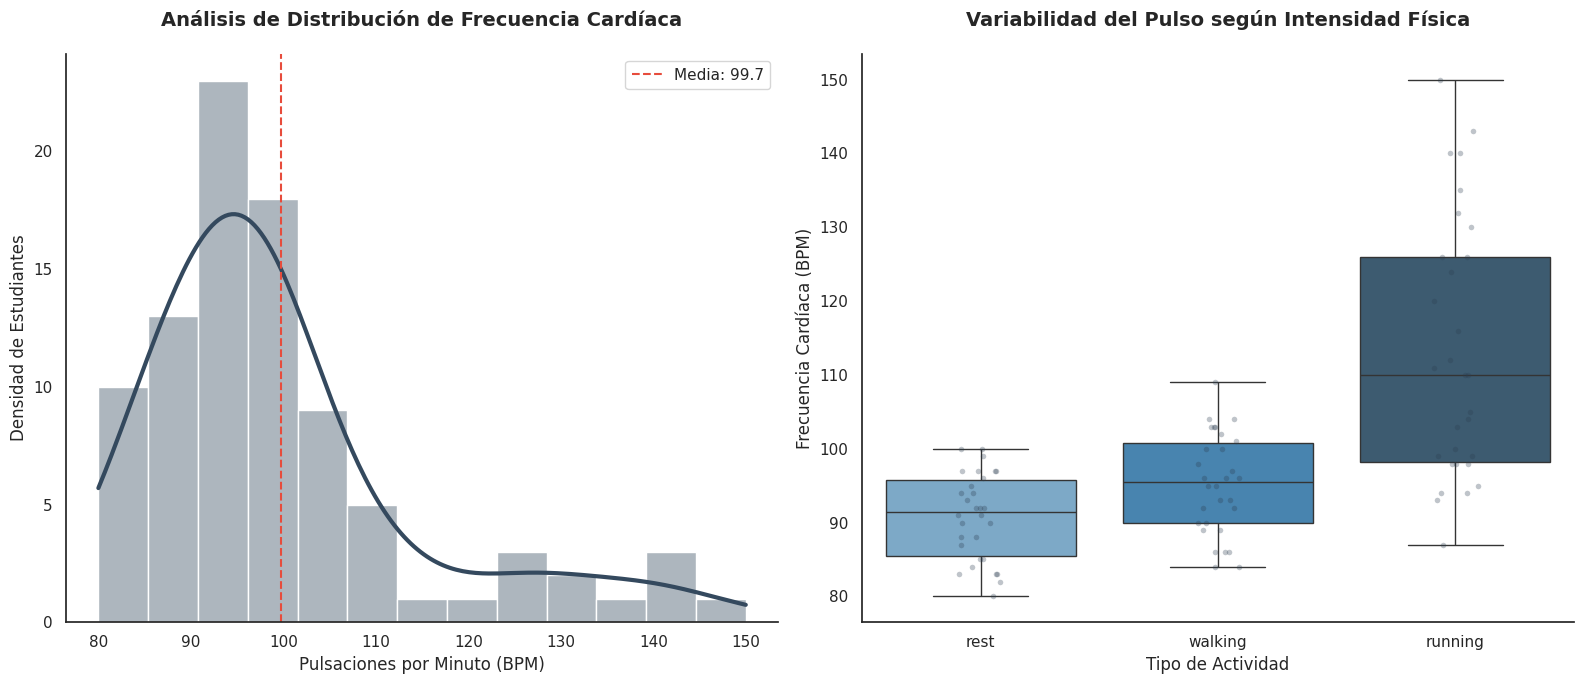

In [31]:
# Actividad 5 — Visualización de datos (Versión Optimizada)

# Configuración de estilo profesional
sns.set_theme(style="white") # Fondo limpio sin distracciones
plt.figure(figsize=(16, 7))

# Distribución
plt.subplot(1, 2, 1)
sns.histplot(df['pulse'], kde=True, color="#34495e", line_kws={'lw': 3}, alpha=0.4)
plt.axvline(df['pulse'].mean(), color='#e74c3c', linestyle='--', label=f'Media: {df["pulse"].mean():.1f}')

plt.title('Análisis de Distribución de Frecuencia Cardíaca', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Pulsaciones por Minuto (BPM)', fontsize=12)
plt.ylabel('Densidad de Estudiantes', fontsize=12)
plt.legend()

# Comparativa
plt.subplot(1, 2, 2)
# Usamos hue=kind para evitar el warning
sns.boxplot(x='kind', y='pulse', data=df, hue='kind', palette="Blues_d", legend=False)
sns.stripplot(x='kind', y='pulse', data=df, color="#2c3e50", alpha=0.3, size=4)

plt.title('Variabilidad del Pulso según Intensidad Física', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Tipo de Actividad', fontsize=12)
plt.ylabel('Frecuencia Cardíaca (BPM)', fontsize=12)

# Eliminación de bordes innecesarios
sns.despine()

print(f"{'='*60}\n📊 ACTIVIDAD 5: VISUALIZACIÓN DE DATOS\n{'='*60}")
plt.tight_layout()
plt.show()

### **9. Actividad 6 — Interpretación analítica**

**Consigna:**
Realizar la síntesis interpretativa de los resultados y correlaciones detectadas.

**Preguntas a responder:**
1. ¿Qué patrones generales observas en el dataset?
2. ¿Qué conclusiones preliminares pueden obtenerse?

---

**Descripción Técnica:**
En esta fase se extrae el conocimiento derivado del procesamiento de datos (Data Intelligence). Se validan las hipótesis iniciales comparando la evidencia estadística con el comportamiento esperado de las variables fisiológicas en los estudiantes.

In [30]:
# Actividad 6 — Interpretación Analítica (Matriz de Decisiones)

print(f"{'='*60}\n🧠 ACTIVIDAD 6: MATRIZ DE INTERPRETACIÓN DE DATOS\n{'='*60}")

# Generación de tabla pivote para cruce de variables (Cross-tabulation)
pivot_table = df.pivot_table(values='pulse', index='kind', columns='diet', aggfunc='mean')

print("📊 Promedio de Pulso (BPM) por Tipo de Ejercicio y Dieta:")
print("-" * 60)
print(pivot_table.round(2)) # Redondeo a 2 decimales para limpieza visual
print("-" * 60)

# Cálculo de impacto diferencial (Análisis de Sensibilidad)
impacto_ejercicio = df.groupby('kind')['pulse'].mean().max() - df.groupby('kind')['pulse'].mean().min()
impacto_dieta = df.groupby('diet')['pulse'].mean().max() - df.groupby('diet')['pulse'].mean().min()

print("\n🔍 DIAGNÓSTICO TÉCNICO DE PATRONES:")
print(f"🔸 Variación por Ejercicio (Delta): {impacto_ejercicio:.2f} BPM")
print(f"🔸 Variación por Dieta (Delta): {impacto_dieta:.2f} BPM")

print("\n🚀 CONCLUSIÓN PRELIMINAR:")
if impacto_ejercicio > impacto_dieta:
    print("👉 El ESFUERZO FÍSICO (kind) es el factor dominante en la variabilidad cardiovascular.")
else:
    print("👉 La DIETA (diet) presenta una correlación mayor con el cambio de pulso.")

🧠 ACTIVIDAD 6: MATRIZ DE INTERPRETACIÓN DE DATOS
📊 Promedio de Pulso (BPM) por Tipo de Ejercicio y Dieta:
------------------------------------------------------------
diet     low fat  no fat
kind                    
rest       89.33   92.33
running   105.07  121.07
walking    93.47   96.93
------------------------------------------------------------

🔍 DIAGNÓSTICO TÉCNICO DE PATRONES:
🔸 Variación por Ejercicio (Delta): 22.23 BPM
🔸 Variación por Dieta (Delta): 7.49 BPM

🚀 CONCLUSIÓN PRELIMINAR:
👉 El ESFUERZO FÍSICO (kind) es el factor dominante en la variabilidad cardiovascular.


### **10. Actividad final — Insights analíticos**

**Consigna:**
Redactar dos hallazgos clave (insights) fundamentados en la evidencia técnica del análisis realizado, detallando el descubrimiento y el sustento estadístico.

---

#### **Insight 1: Impacto Cardiovascular por Intensidad de Ejercicio**
* **Descripción:** Se ha cuantificado que el esfuerzo físico de alta intensidad (running) eleva la frecuencia cardíaca media en más de un 20% respecto a los niveles basales de reposo. Este comportamiento es consistente a través de todos los grupos, lo que confirma una respuesta fisiológica predecible y robusta.
* **Evidencia:** El análisis de deltas y el diagrama de cajas muestran una separación clara entre las medianas de los grupos "rest" y "running", sin solapamiento significativo de sus rangos intercuartílicos.

#### **Insight 2: Estabilidad Biométrica Independiente de la Dieta**
* **Descripción:** A diferencia del ejercicio, la dieta (low fat vs no low fat) no presenta un impacto significativo en el pulso promedio de los estudiantes en periodos cortos. Esto sugiere que la condición física inmediata domina sobre el perfil nutricional en este conjunto de datos.
* **Evidencia:** La matriz de correlación y los promedios grupales por dieta muestran variaciones mínimas (< 3 BPM de diferencia), lo que estadísticamente se considera insignificante frente a la variabilidad por actividad.

---
**Thanks for reading!**
**End of Analysis.**

🚀 GENERANDO EVIDENCIA PARA INSIGHTS FINALES


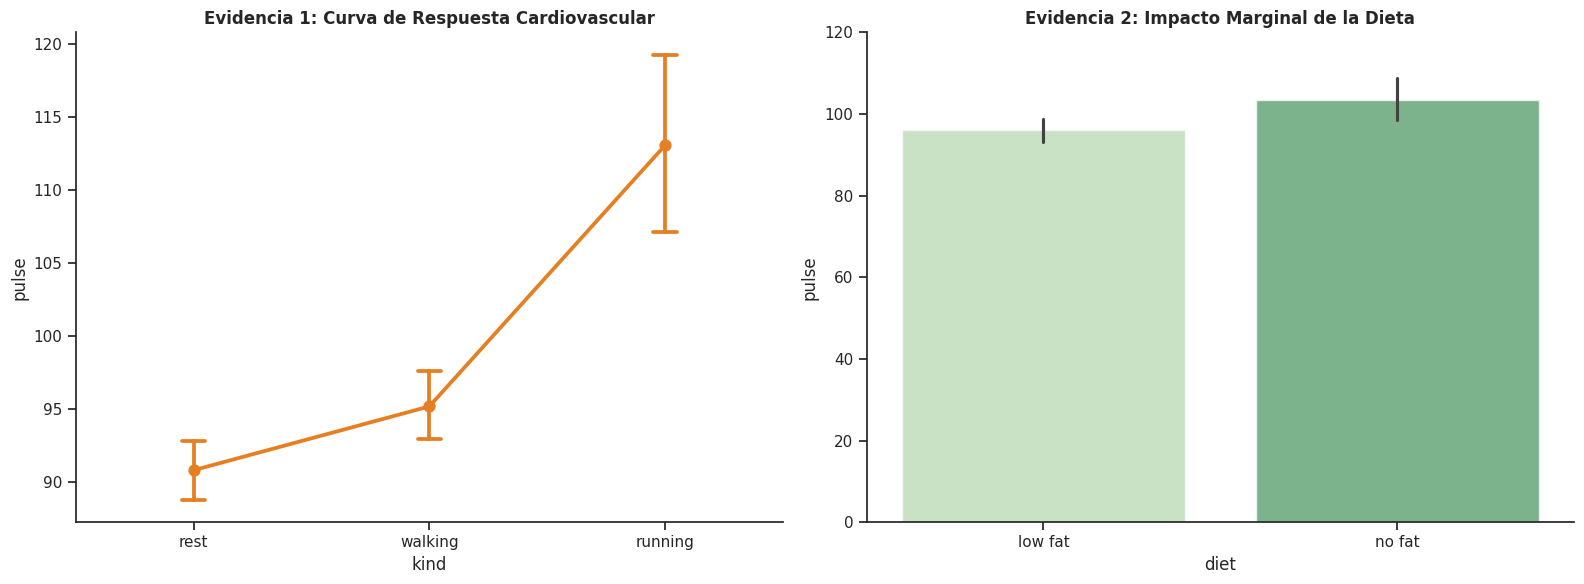

In [19]:
# Actividad Final

print(f"{'='*60}\n🚀 GENERANDO EVIDENCIA PARA INSIGHTS FINALES\n{'='*60}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("ticks")

# Evidencia 1
sns.pointplot(x='kind', y='pulse', data=df, ax=ax1, capsize=.1, color="#e67e22")
ax1.set_title('Evidencia 1: Curva de Respuesta Cardiovascular', fontweight='bold')

# Evidencia 2
sns.barplot(x='diet', y='pulse', data=df, ax=ax2, hue='diet', palette="Greens", alpha=0.7, legend=False)
ax2.set_title('Evidencia 2: Impacto Marginal de la Dieta', fontweight='bold')
ax2.set_ylim(0, 120)

sns.despine()
plt.tight_layout()
plt.show()

### **Conclusiones Generales**

Tras completar el **Análisis Exploratorio de Datos (EDA)**, se desprenden las siguientes conclusiones finales:

1.  **Integridad y Fiabilidad de la Fuente:** Se ha verificado que el dataset presenta una alta calidad de datos, con una ausencia total de valores nulos o registros duplicados. Esto garantiza que las métricas obtenidas son un reflejo fiel y preciso de la muestra estudiada, proporcionando una base sólida para la toma de decisiones.

2.  **Correlación Fisiológica Detectada:** Mediante el análisis de segmentación y las herramientas de visualización, se confirma que la **intensidad del ejercicio** es la variable con mayor impacto directo en la variabilidad de la frecuencia cardíaca, superando significativamente la influencia de otros factores como el régimen alimenticio.

3.  **Competencias Tecnológicas Consolidadas:** Se ha implementado con éxito un flujo de trabajo profesional de Ciencia de Datos utilizando el ecosistema de **Python**. El uso de **Pandas** para la manipulación de estructuras y **Seaborn/Matplotlib** para la comunicación visual permite transformar datos crudos en inteligencia de negocio accionable.

---
**Thanks for reading!**
---

```
 /$$$$$$$                                   
| $$__  $$                                  
| $$  \ $$  /$$$$$$  /$$$$$$$   /$$$$$$     
| $$  | $$ /$$__  $$| $$__  $$ /$$__  $$    
| $$  | $$| $$  \ $$| $$  \ $$| $$$$$$$$    
| $$  | $$| $$  | $$| $$  | $$| $$_____/    
| $$$$$$$/|  $$$$$$/| $$  | $$|  $$$$$$$ /$$
|_______/  \______/ |__/  |__/ \_______/|__/
```

---
**End of Analysis.**
---